Para a animação ser gerada sem problemas, descomente a linha do pip install e instale esse paconte em sua venv

In [1]:
# %pip install ipympl
%matplotlib widget

## Construção da Treliça e Obtenção dos resultados com a Eliminação de Gauss

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from Algoritmos.Trelica.Ktotal import KTotal
from Algoritmos.Trelica.Kreduzida import KReduzida
from Algoritmos.Trelica.Desloc import deslocamento_max
from Algoritmos.MetodosNumericos.ElimGauss import eliminacao_gaussiana

# Definições iniciais
bars = []
connects = []

r = 2
alpha = 30

# Montar os nós
connects.append((0,0))
for theta in range(180, -1, -alpha):
    
    theta_rad = math.radians(theta)
    x = math.cos(theta_rad)*r
    y = math.sin(theta_rad)*r

    connects.append((x, y))

# Montar as arestas
for i in range(1, len(connects)):
    bars.append((0, i, r))

dist = 2*r*math.sin(math.radians(alpha/2))
for i in range(1, len(connects)-1):
    bars.append((i, i+1, dist))


# Calcular o Ktotal
Ktot = KTotal(bars, connects)
Kred, free = KReduzida(Ktot)

deslocs = []
solucoes = []

for b in range (1, 101):
    F = 1000*b
    print("==============================================================")
    print(f"Força aplicada: {F}N")
    vec_forcas = np.array([
        0, -F, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ], dtype=float)
    Fred = vec_forcas[free]

    ###############
    # Elim. Gauss #
    ###############

    r = eliminacao_gaussiana(Kred, Fred)

    u_global = np.zeros(Ktot.shape[0])
    for i, grau in enumerate(free):
        u_global[grau] = r[i]
    
    solucoes.append(u_global.copy())
    deslocs.append(deslocamento_max(connects, u_global))


Força aplicada: 1000N
Força aplicada: 2000N
Força aplicada: 3000N
Força aplicada: 4000N
Força aplicada: 5000N
Força aplicada: 6000N
Força aplicada: 7000N
Força aplicada: 8000N
Força aplicada: 9000N
Força aplicada: 10000N
Força aplicada: 11000N
Força aplicada: 12000N
Força aplicada: 13000N
Força aplicada: 14000N
Força aplicada: 15000N
Força aplicada: 16000N
Força aplicada: 17000N
Força aplicada: 18000N
Força aplicada: 19000N
Força aplicada: 20000N
Força aplicada: 21000N
Força aplicada: 22000N
Força aplicada: 23000N
Força aplicada: 24000N
Força aplicada: 25000N
Força aplicada: 26000N
Força aplicada: 27000N
Força aplicada: 28000N
Força aplicada: 29000N
Força aplicada: 30000N
Força aplicada: 31000N
Força aplicada: 32000N
Força aplicada: 33000N
Força aplicada: 34000N
Força aplicada: 35000N
Força aplicada: 36000N
Força aplicada: 37000N
Força aplicada: 38000N
Força aplicada: 39000N
Força aplicada: 40000N
Força aplicada: 41000N
Força aplicada: 42000N
Força aplicada: 43000N
Força aplicada: 4400

In [3]:
print(deslocs[98])

0.01222034774259583


## Plotagem do gráfico Deslocamento máximo X Força aplicada

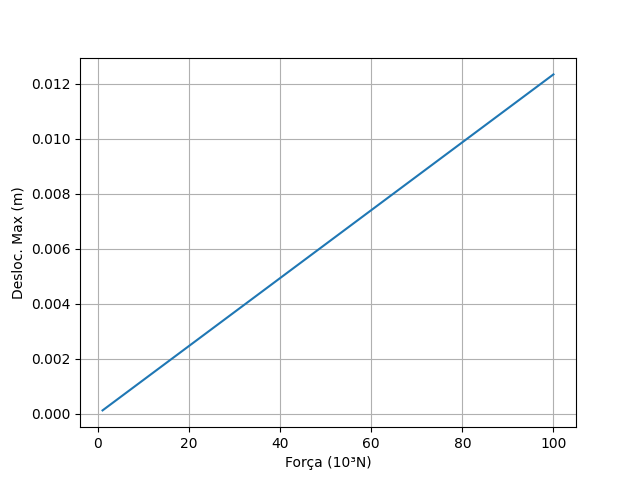

In [ ]:
plt.plot(range(1,101), deslocs)
plt.xlabel("Força (kN)")
plt.ylabel("Desloc. Max (m)")
plt.grid(True)
plt.show()

## Definição de funções úteis para a animação

In [5]:
def coordenadas_deformadas(connects, u_global, escala=15):
    c_def = []

    for no in range(len(connects)):
        x,y = connects[no]

        desloc_x = u_global[2*no]
        desloc_y = u_global[2*no+1]

        c_def.append((x + escala*desloc_x, y + escala*desloc_y))

    return c_def

def desenha_trelica(coords, bars, ax, color="black"):
    for no1, no2, _ in bars:
        x1, y1 = coords[no1]
        x2, y2 = coords[no2]
        ax.plot(
            [x1, x2],
            [y1, y2],
            color = color
        )

    
    x_no0, y_no0 = coords[0]

    ax.annotate(
        text='',
        xy=(x_no0, y_no0-0.4),
        xytext=(x_no0, y_no0),
        arrowprops=dict(
            facecolor='purple',
            edgecolor='purple',
            shrink=0.05,
            width=2,
            headwidth=8
        )
    )
    
    ax.text(
        x_no0 + 0.1, 
        y_no0 - 0.2, 
        r'$F$', 
        color='purple', 
        fontsize=12, 
        ha='center', 
        va='bottom'
    )

    ax.set_aspect('equal')
    ax.grid(True)
    

## Testando o plot da treliça com diferentes forças

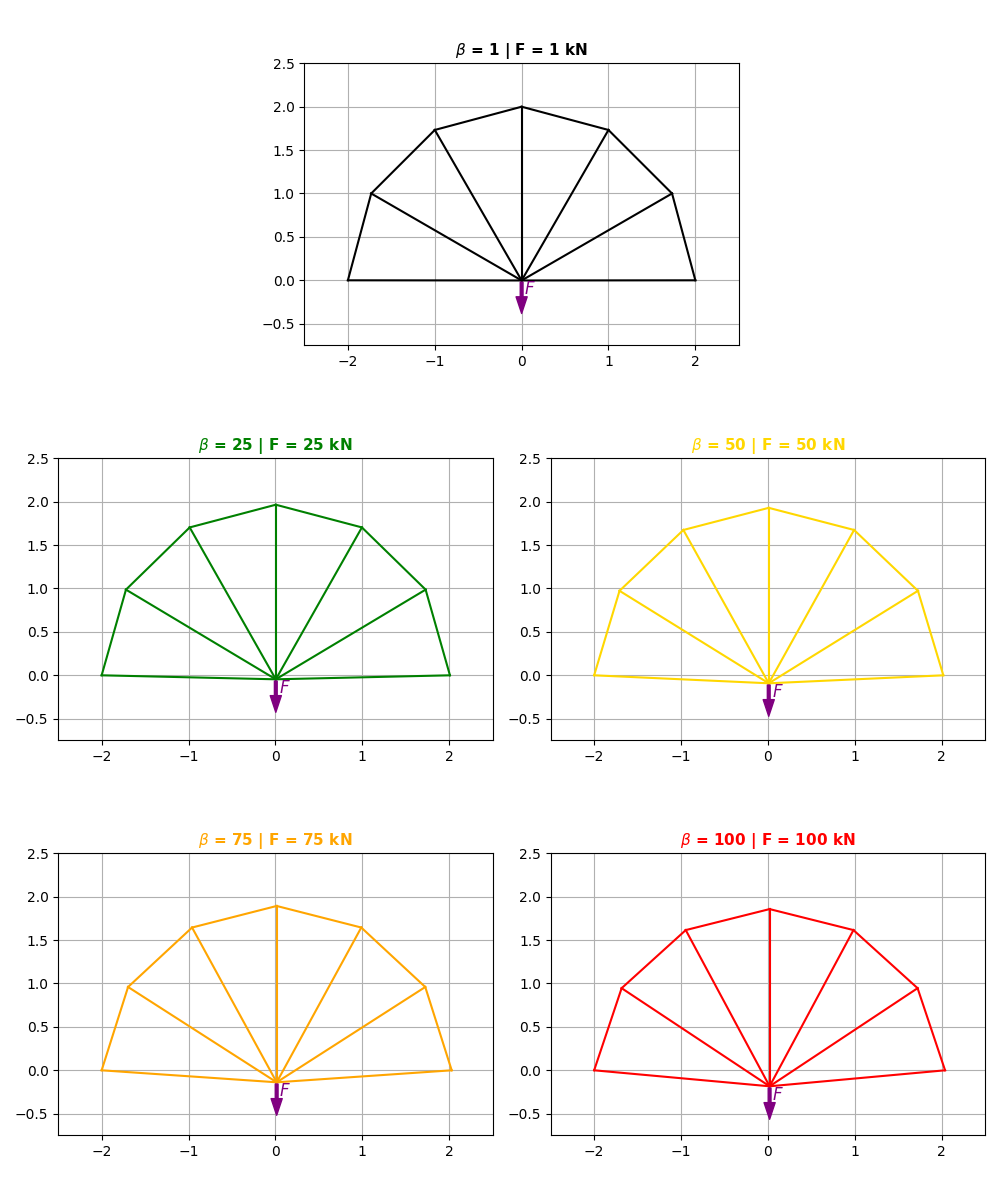

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 12))

gs = gridspec.GridSpec(3, 4, figure=fig)

axes_loc = [
    gs[0, 1:3],  # Topo centralizado
    gs[1, 0:2],  # Meio esquerda
    gs[1, 2:4],  # Meio direita
    gs[2, 0:2],  # Base esquerda
    gs[2, 2:4]   # Base direita
]

frames_desejados = [1-1, 25-1, 50-1, 75-1, 100-1]
cores = ["black", "green", "gold", "orange", "red"]

for i, frame in enumerate(frames_desejados):
    ax = fig.add_subplot(axes_loc[i])
    
    ax.set_ylim(-0.75, 2.5)
    ax.set_xlim(-2.5, 2.5)
    
    beta = frame + 1
    forca_kn = beta
    
    c_def = coordenadas_deformadas(connects, solucoes[frame], 15)
    desenha_trelica(c_def, bars, ax, color=cores[i])
    
    ax.set_title(f"$\\beta$ = {beta} | F = {forca_kn} kN", fontsize=11, color=cores[i], fontweight='bold')

plt.tight_layout()
plt.show()

# Animação

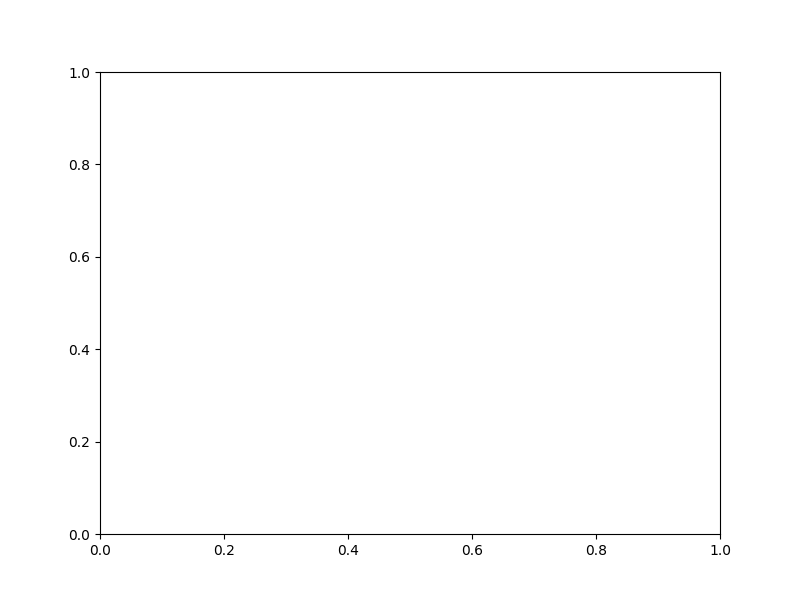

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame, connects, solucoes):
    ax.clear()

    print(frame)
    u = solucoes[frame]
    c_def = coordenadas_deformadas(connects, u, 15)
    
    desenha_trelica(c_def, bars, ax)

    ax.set_ylim(-0.75, 2.5)
    ax.set_title(f"F = {frame+1} 10³ N")
    

ani = FuncAnimation(
    fig,
    update,
    frames=len(solucoes),
    fargs=(connects, solucoes),
    interval=100,
    repeat_delay=500,
    repeat=True
)

# Para salvar como gif descomente essa linha
# ani.save('trelica_deformacao.gif', writer='pillow', fps=10)

plt.show()